# Cross-Layer KV Sharing

This bonus material illustrates the memory savings when using cross-layer KV sharing together with a KV cache.

&nbsp;
## Introduction

In [../04_gqa](../04_gqa), we discussed Grouped-Query Attention (GQA), where several query heads share the same key and value heads. Cross-layer KV sharing applies a related idea across transformer layers.

Instead of computing a fresh key and value projection in every layer, later layers reuse K/V tensors from an earlier layer. They still compute their own queries, so each layer can form its own attention pattern. The main memory saving comes from storing fewer K/V tensors in the cache.

This idea is also called cross-layer attention. It is described in Brandon *et al.*, [Reducing Transformer Key-Value Cache Size with Cross-Layer Attention](https://arxiv.org/abs/2405.12981). Gemma 4 E2B and E4B use a related shared KV-cache scheme, which makes this a useful addition to the GQA, MLA, and SWA examples in this chapter.

&nbsp;

<img src="https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch04/10_kv-sharing/gemma4-kv-sharing.webp" alt="Cross-layer KV sharing" width="800px" />

&nbsp;

In [Gemma 4](../../ch05/17_gemma4), KV sharing is combined with GQA or MQA and sliding window attention. For the simplified GPT example in this folder, we only implement the cross-layer KV-sharing part, so the code stays focused on the main mechanism.

The simplified rule used here is:

1. Early layers compute and cache their own K/V tensors.
2. Later layers reuse the most recent K/V tensors from an earlier producing layer.
3. All layers still compute their own query projections.

This reduces the number of K/V caches that grow with context length. The tradeoff is reduced model capacity because some layers no longer get their own K/V projections.

&nbsp;
## KV-Sharing Memory Savings

The usual KV-cache memory is computed as follows:

bytes = batch_size x seqlen x head_dim x n_kv_heads x n_layers x 2 (K,V) x bytes_per_elem

With cross-layer KV sharing, we replace `n_layers` with the number of K/V-producing layers:

bytes = batch_size x seqlen x head_dim x n_kv_heads x n_kv_producing_layers x 2 (K,V) x bytes_per_elem

You can use the [memory_estimator_kv_sharing.py](memory_estimator_kv_sharing.py) script in this folder to apply this to different model configs:

```bash
# Gemma 4 E2B-like setup
uv run memory_estimator_kv_sharing.py \
  --context_length 131072 \
  --emb_dim 2048 \
  --n_heads 8 \
  --n_layers 35 \
  --n_kv_groups 8 \
  --n_kv_producing_layers 15 \
  --batch_size 1 \
  --dtype bf16

# Gemma 4 E4B-like setup
# uv run memory_estimator_kv_sharing.py \
#   --context_length 131072 \
#   --emb_dim 2560 \
#   --n_heads 8 \
#   --n_layers 42 \
#   --n_kv_groups 4 \
#   --n_kv_producing_layers 24 \
#   --batch_size 1 \
#   --dtype bf16

==== Config ====
context_length         : 131072
emb_dim                : 2048
n_heads                : 8
n_layers               : 35
n_kv_groups            : 8
n_kv_producing_layers  : 15
batch_size             : 1
dtype                  : bf16 (2 Bytes/elem)
head_dim               : 256
GQA n_kv_heads         : 1

==== KV-cache totals across all layers ====
MHA total KV cache        : 37.58 GB
GQA total KV cache        : 4.70 GB
MHA + KV sharing          : 16.11 GB
GQA + KV sharing          : 2.01 GB
Ratio (MHA / GQA+sharing) : 18.67x
Savings vs MHA            : 94.64%
```

This is a Gemma 4 E2B-like setup. The 35 layers include 15 K/V-producing layers, and the remaining layers reuse earlier K/V tensors. For the E4B-like setup, the corresponding numbers are 42 total layers and 24 K/V-producing layers.

The savings are shown below for the E2B-like and E4B-like setups. For simplicity, these plots do not include additional savings from sliding window attention.

&nbsp;

<img src="https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch04/10_kv-sharing/kv_memory_mha_gqa_kvsharing_gemma4_e2b.webp" alt="KV-sharing memory savings for Gemma 4 E2B-like setup" width="800px" />

&nbsp;

<img src="https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch04/10_kv-sharing/kv_memory_mha_gqa_kvsharing_gemma4_e4b.webp" alt="KV-sharing memory savings for Gemma 4 E4B-like setup" width="800px" />

&nbsp;

You can reproduce similar plots via:

```bash
uv run plot_memory_estimates_kv_sharing.py --preset gemma4_e2b
uv run plot_memory_estimates_kv_sharing.py --preset gemma4_e4b
```

In [1]:
!git clone --depth 1 https://github.com/rasbt/LLMs-from-scratch.git

Cloning into 'LLMs-from-scratch'...
remote: Enumerating objects: 434, done.
remote: Counting objects: 100% (434/434), done.
remote: Compressing objects: 100% (320/320), done.
remote: Total 434 (delta 104), reused 423 (delta 101), pack-reused 0 (from 0)
Receiving objects: 100% (434/434), 2.24 MiB | 24.42 MiB/s, done.
Resolving deltas: 100% (104/104), done.


In [2]:
%cd /kaggle/working/LLMs-from-scratch/ch04/10_kv-sharing

/kaggle/working/LLMs-from-scratch/ch04/10_kv-sharing


In [3]:
# Gemma 4 E2B-like setup
!uv run memory_estimator_kv_sharing.py \
  --context_length 131072 \
  --emb_dim 2048 \
  --n_heads 8 \
  --n_layers 35 \
  --n_kv_groups 8 \
  --n_kv_producing_layers 15 \
  --batch_size 1 \
  --dtype bf16


Using CPython 3.12.13 interpreter at: /usr/bin/python3
Creating virtual environment at: /kaggle/working/LLMs-from-scratch/.venv
░░░░░░░░░░░░░░░░░░░░ [0/170] Installing wheels...                               warning: Failed to hardlink files; falling back to full copy. This may lead to degraded performance.
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 170 packages in 20.89s                            
==== Config ====
context_length         : 131072
emb_dim                : 2048
n_heads                : 8
n_layers               : 35
n_kv_groups            : 8
n_kv_producing_layers  : 15
batch_size             : 1
dtype                  : bf16 (2 Bytes/elem)
head_dim               : 256
GQA n_kv_heads         : 1

==== KV-cache totals across all layers ====
MHA total KV cache        : 37.58 GB
GQA to

In [4]:
# Gemma 4 E4B-like setup
!uv run memory_estimator_kv_sharing.py \
  --context_length 131072 \
  --emb_dim 2560 \
  --n_heads 8 \
  --n_layers 42 \
  --n_kv_groups 4 \
  --n_kv_producing_layers 24 \
  --batch_size 1 \
  --dtype bf16

==== Config ====
context_length         : 131072
emb_dim                : 2560
n_heads                : 8
n_layers               : 42
n_kv_groups            : 4
n_kv_producing_layers  : 24
batch_size             : 1
dtype                  : bf16 (2 Bytes/elem)
head_dim               : 320
GQA n_kv_heads         : 2

==== KV-cache totals across all layers ====
MHA total KV cache        : 56.37 GB
GQA total KV cache        : 14.09 GB
MHA + KV sharing          : 32.21 GB
GQA + KV sharing          : 8.05 GB
Ratio (MHA / GQA+sharing) : 7.00x
Savings vs MHA            : 85.71%


In [5]:
!pip install pymupdf Pillow

import fitz  # PyMuPDF
from PIL import Image
import io

def displayPDF(pdf_path):
    doc = fitz.open(pdf_path)
    
    # Loop through pages, convert them to images, and display
    for page_num in range(len(doc)):
        page = doc.load_page(page_num)
        pix = page.get_pixmap()
        
        # Convert raw pixmap bytes to an image data format
        img_data = pix.tobytes("png")
        img = Image.open(io.BytesIO(img_data))
        
        # Display it in the notebook output
        display(img)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 68.7 MB/s eta 0:00:00:00:0100:01


In [6]:
!uv run plot_memory_estimates_kv_sharing.py --preset gemma4_e2b
!uv run plot_memory_estimates_kv_sharing.py --preset gemma4_e4b

Saved plot to: kv_memory_mha_gqa_kvsharing_gemma4_e2b.pdf
Saved plot to: kv_memory_mha_gqa_kvsharing_gemma4_e4b.pdf


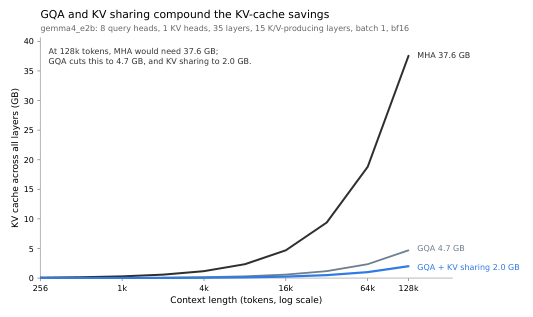

In [7]:
# Gemma 4 E2B-like setup
displayPDF("/kaggle/working/LLMs-from-scratch/ch04/10_kv-sharing/kv_memory_mha_gqa_kvsharing_gemma4_e2b.pdf")

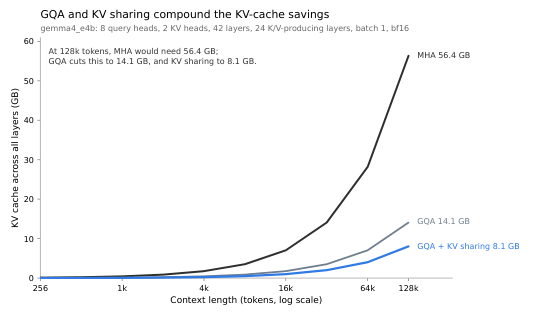

In [8]:
# Gemma 4 E4B-like setup
displayPDF("/kaggle/working/LLMs-from-scratch/ch04/10_kv-sharing/kv_memory_mha_gqa_kvsharing_gemma4_e4b.pdf")

&nbsp;
## KV-Sharing Code Examples

The [gpt_with_kv_mha.py](gpt_with_kv_mha.py) and [gpt_with_kv_sharing.py](gpt_with_kv_sharing.py) scripts in this folder provide hands-on examples for comparing regular MHA with a cross-layer KV-sharing variant.

The easiest way to see the implementation details is to inspect a file diff between [gpt_with_kv_mha.py](gpt_with_kv_mha.py) and [gpt_with_kv_sharing.py](gpt_with_kv_sharing.py). The comments are intentionally kept similar so that the diff highlights the KV-sharing changes.

Note that the model is not trained and thus generates nonsensical text. However, you can use it as a drop-in replacement for the standard GPT model in chapters 5-7 and train it.

Also, this implementation uses the KV cache explained in [another bonus section](../03_kv-cache), so the memory savings are more pronounced.

```bash
uv run gpt_with_kv_mha.py \
--max_new_tokens 32768 \
--n_heads 24 \
--n_layers 12 \
--emb_dim 768
```

```bash
uv run gpt_with_kv_sharing.py \
--max_new_tokens 32768 \
--n_heads 24 \
--n_layers 12 \
--emb_dim 768 \
--n_kv_producing_layers 6
```

In this small GPT setup, the whole model still contains the same feed-forward layers and output head. The main memory difference is in how many attention layers store K/V tensors in the cache.

In [ ]:
!uv run gpt_with_kv_mha.py \
--max_new_tokens 32768 \
--n_heads 24 \
--n_layers 12 \
--emb_dim 768

In [ ]:
!uv run gpt_with_kv_sharing.py \
--max_new_tokens 32768 \
--n_heads 24 \
--n_layers 12 \
--emb_dim 768 \
--n_kv_producing_layers 6